In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [46]:
df = pd.read_csv('flights_sample_3m.csv')

In [47]:
df.shape

(3000000, 32)

In [48]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [49]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# Filtrar solo el año 2022
df_2022 = df[df['FL_DATE'].dt.year == 2022]

# Traducir nombres de columnas al español
columnas_es = {
    'FL_DATE': 'fecha_vuelo',
    'AIRLINE': 'aerolinea',
    'AIRLINE_DOT': 'aerolinea_dot',
    'AIRLINE_CODE': 'codigo_aerolinea',
    'DOT_CODE': 'codigo_dot',
    'FL_NUMBER': 'numero_vuelo',
    'ORIGIN': 'origen',
    'ORIGIN_CITY': 'ciudad_origen',
    'DEST': 'destino',
    'DEST_CITY': 'ciudad_destino',
    'CRS_DEP_TIME': 'hora_salida_programada',
    'DEP_TIME': 'hora_salida_real',
    'DEP_DELAY': 'retraso_salida',
    'TAXI_OUT': 'tiempo_rodaje_salida',
    'WHEELS_OFF': 'despegue',
    'WHEELS_ON': 'aterrizaje',
    'TAXI_IN': 'tiempo_rodaje_llegada',
    'CRS_ARR_TIME': 'hora_llegada_programada',
    'ARR_TIME': 'hora_llegada_real',
    'ARR_DELAY': 'retraso_llegada',
    'CANCELLED': 'cancelado',
    'CANCELLATION_CODE': 'codigo_cancelacion',
    'DIVERTED': 'desviado',
    'CRS_ELAPSED_TIME': 'duracion_programada',
    'ELAPSED_TIME': 'duracion_real',
    'AIR_TIME': 'tiempo_en_aire',
    'DISTANCE': 'distancia',
    'DELAY_DUE_CARRIER': 'retraso_por_aerolinea',
    'DELAY_DUE_WEATHER': 'retraso_por_clima',
    'DELAY_DUE_NAS': 'retraso_por_trafico_aereo',
    'DELAY_DUE_SECURITY': 'retraso_por_seguridad',
    'DELAY_DUE_LATE_AIRCRAFT': 'retraso_por_avion_tardio'
}

df_2022 = df_2022.rename(columns=columnas_es)

print(f"Filas: {len(df_2022)}")
print(df_2022.columns.tolist())

Filas: 687860
['fecha_vuelo', 'aerolinea', 'aerolinea_dot', 'codigo_aerolinea', 'codigo_dot', 'numero_vuelo', 'origen', 'ciudad_origen', 'destino', 'ciudad_destino', 'hora_salida_programada', 'hora_salida_real', 'retraso_salida', 'tiempo_rodaje_salida', 'despegue', 'aterrizaje', 'tiempo_rodaje_llegada', 'hora_llegada_programada', 'hora_llegada_real', 'retraso_llegada', 'cancelado', 'codigo_cancelacion', 'desviado', 'duracion_programada', 'duracion_real', 'tiempo_en_aire', 'distancia', 'retraso_por_aerolinea', 'retraso_por_clima', 'retraso_por_trafico_aereo', 'retraso_por_seguridad', 'retraso_por_avion_tardio']


In [50]:
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687860 entries, 1 to 2999997
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   fecha_vuelo                687860 non-null  datetime64[ns]
 1   aerolinea                  687860 non-null  object        
 2   aerolinea_dot              687860 non-null  object        
 3   codigo_aerolinea           687860 non-null  object        
 4   codigo_dot                 687860 non-null  int64         
 5   numero_vuelo               687860 non-null  int64         
 6   origen                     687860 non-null  object        
 7   ciudad_origen              687860 non-null  object        
 8   destino                    687860 non-null  object        
 9   ciudad_destino             687860 non-null  object        
 10  hora_salida_programada     687860 non-null  int64         
 11  hora_salida_real           669844 non-null  float64     

In [51]:
df_2022.nunique()

fecha_vuelo                   365
aerolinea                      17
aerolinea_dot                  17
codigo_aerolinea               17
codigo_dot                     17
numero_vuelo                 6594
origen                        370
ciudad_origen                 364
destino                       370
ciudad_destino                364
hora_salida_programada       1293
hora_salida_real             1431
retraso_salida               1136
tiempo_rodaje_salida          171
despegue                     1432
aterrizaje                   1440
tiempo_rodaje_llegada         167
hora_llegada_programada      1386
hora_llegada_real            1440
retraso_llegada              1167
cancelado                       2
codigo_cancelacion              4
desviado                        2
duracion_programada           566
duracion_real                 660
tiempo_en_aire                632
distancia                    1590
retraso_por_aerolinea         935
retraso_por_clima             451
retraso_por_tr

In [52]:
nulos = df_2022.isnull().sum()
pct_nulos = (nulos / len(df_2022) * 100).round(2)
resumen_nulos = pd.DataFrame({'Cantidad': nulos, 'Porcentaje (%)': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['Cantidad'] > 0].sort_values('Porcentaje (%)', ascending=False)
print('Columnas con valores nulos:')
resumen_nulos

Columnas con valores nulos:


,Cantidad,Porcentaje (%)
codigo_cancelacion,669412,97.32
retraso_por_clima,547392,79.58
retraso_por_avion_tardio,547392,79.58
retraso_por_trafico_aereo,547392,79.58
retraso_por_aerolinea,547392,79.58
retraso_por_seguridad,547392,79.58
retraso_llegada,20099,2.92
tiempo_en_aire,20099,2.92
duracion_real,20099,2.92
tiempo_rodaje_llegada,18625,2.71


In [53]:
import requests
import time


# 1. Preparar fecha y reducir volumen (muestra estratificada + top aeropuertos)

df_2022['fecha_vuelo'] = pd.to_datetime(df_2022['fecha_vuelo'])
df_2022['mes'] = df_2022['fecha_vuelo'].dt.month

df_2022 = df_2022.groupby('mes', group_keys=False).apply(
    lambda x: x.sample(frac=0.25, random_state=42)
)

top_aeropuertos = df_2022['origen'].value_counts()
cobertura = top_aeropuertos.cumsum() / top_aeropuertos.sum()
aeropuertos_relevantes = cobertura[cobertura <= 0.90].index.tolist()

df_2022 = df_2022[df_2022['origen'].isin(aeropuertos_relevantes)]
print(f"Filas después de reducir: {len(df_2022)} | Aeropuertos: {len(aeropuertos_relevantes)}")

Filas después de reducir: 154586 | Aeropuertos: 92


C:\Users\carro\AppData\Local\Temp\ipykernel_8156\1903487106.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_2022 = df_2022.groupby('mes', group_keys=False).apply(


Nos quedamos con una muestra del dataset y con los aeropuertos que conforman parte del top para poder correr el request y que no sea tan pesado.

In [54]:
# 2. Crear variable objetivo ANTES de filtrar columnas

df_2022['retrasado'] = (df_2022['retraso_salida'] > 15).astype(int)

Definimos la variable objetivo con solo aquellos vuelos que se retrasaron más de 15 minutos

In [55]:
# 3. Traer coordenadas de los aeropuertos relevantes (solo esos, no todos)

airports_db = pd.read_csv("https://ourairports.com/data/airports.csv")
airports_db = airports_db[airports_db['iata_code'].isin(aeropuertos_relevantes)]
airports_db = airports_db[['iata_code', 'latitude_deg', 'longitude_deg']].dropna()
airports_db = airports_db.rename(columns={'iata_code': 'origen', 'latitude_deg': 'lat', 'longitude_deg': 'lon'})

Nos traemos las coordenadas de los aeropuertos para luego buscar el clima para cada una de las fechas.

In [56]:
# 4. Pedir clima solo para esos aeropuertos (un request por aeropuerto, año completo)

clima_data = []
for i, row in airports_db.iterrows():
    try:
        response = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params={
                "latitude": row['lat'],
                "longitude": row['lon'],
                "start_date": "2022-01-01",
                "end_date": "2022-12-31",
                "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
                "timezone": "America/New_York"
            },
            timeout=30
        )
        data = response.json()
        temp = pd.DataFrame({
            'fecha_vuelo': data['daily']['time'],
            'temperatura_media': data['daily']['temperature_2m_mean'],
            'precipitacion': data['daily']['precipitation_sum'],
            'viento_max': data['daily']['windspeed_10m_max']
        })
        temp['origen'] = row['origen']
        clima_data.append(temp)
        print(f"OK: {row['origen']} ({i+1}/{len(airports_db)})")
    except Exception as e:
        print(f"Error con {row['origen']}: {e}")
    time.sleep(0.5)

clima_data = pd.concat(clima_data, ignore_index=True)
clima_data['fecha_vuelo'] = pd.to_datetime(clima_data['fecha_vuelo'])

OK: ABQ (38564/92)
OK: ALB (38624/92)
OK: ATL (38684/92)
OK: AUS (38693/92)
OK: BDL (38740/92)
OK: BHM (38768/92)
OK: BNA (38803/92)
OK: BOI (38808/92)
OK: BOS (38810/92)
OK: BUF (38835/92)
OK: BUR (38837/92)
OK: BWI (38849/92)
OK: CHS (38947/92)
OK: CLE (38968/92)
OK: CLT (38975/92)
OK: CMH (38979/92)
OK: COS (39002/92)
OK: CVG (39043/92)
OK: DAL (39102/92)
OK: DCA (39108/92)
OK: DEN (39117/92)
OK: DFW (39122/92)
OK: DSM (39161/92)
OK: DTW (39168/92)
OK: ELP (39602/92)
OK: EWR (39646/92)
OK: FLL (39744/92)
OK: GEG (39881/92)
OK: GRR (39940/92)
OK: GSP (39944/92)
OK: HOU (40068/92)
OK: HPN (40069/92)
OK: IAD (40161/92)
OK: IAH (40163/92)
OK: IND (40196/92)
OK: JAX (40233/92)
OK: JFK (40241/92)
OK: LAS (40349/92)
OK: LAX (40351/92)
OK: LGA (40376/92)
OK: LGB (40377/92)
OK: MCI (40553/92)
OK: MCO (40556/92)
OK: MDW (40567/92)
OK: MEM (40572/92)
OK: MIA (40598/92)
OK: MKE (40611/92)
OK: MSP (40681/92)
OK: MSY (40684/92)
OK: MYR (40719/92)
OK: OAK (40858/92)
OK: OKC (40885/92)
OK: OMA (409

Nos traemos el clima para cada aeropuerto y fecha.

In [57]:
# 5. Unir clima con vuelos

df_2022 = df_2022.merge(clima_data, on=['origen', 'fecha_vuelo'], how='left')

Hacemos el merge para que el dataset tenga la info del clima.

In [58]:
# 6. Selección final de columnas válidas (sin leakage) → df_modelo

columnas_validas = [
    'fecha_vuelo', 'aerolinea', 'codigo_aerolinea', 'numero_vuelo',
    'origen', 'ciudad_origen', 'destino', 'ciudad_destino',
    'hora_salida_programada', 'hora_llegada_programada',
    'duracion_programada', 'distancia',
    'temperatura_media', 'precipitacion', 'viento_max'
]

df_modelo = df_2022[columnas_validas + ['retrasado']]

print(f"\nFilas finales en df_modelo: {len(df_modelo)}")
print(df_modelo.columns.tolist())


Filas finales en df_modelo: 154586
['fecha_vuelo', 'aerolinea', 'codigo_aerolinea', 'numero_vuelo', 'origen', 'ciudad_origen', 'destino', 'ciudad_destino', 'hora_salida_programada', 'hora_llegada_programada', 'duracion_programada', 'distancia', 'temperatura_media', 'precipitacion', 'viento_max', 'retrasado']


Nos quedamos únicamente con estas columnas porque el resto tiene muchos nulos y además porque podrían generar un leakage ya que son columnas que describían cosas que habían pasado luego del hecho generador que estamos analizando, si usaramos esas columnas para entrenar el modelo estaríamos haciendo trampa.

In [59]:
#Quiero separar en categóricas y numéricas, para poder hacer un análisis más profundo de los datos. 
categorical_columns = df_modelo.select_dtypes(include=['object']).columns
numerical_columns = df_modelo.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)


Categorical columns: Index(['aerolinea', 'codigo_aerolinea', 'origen', 'ciudad_origen', 'destino',
       'ciudad_destino'],
      dtype='object')
Numerical columns: Index(['numero_vuelo', 'hora_salida_programada', 'hora_llegada_programada',
       'duracion_programada', 'distancia', 'temperatura_media',
       'precipitacion', 'viento_max', 'retrasado'],
      dtype='object')


Análisis Outliers

In [60]:
for col in numerical_columns:
    Q1 = df_2022[col].quantile(0.25)
    Q3 = df_2022[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_2022[(df_modelo[col] < lower_bound) | (df_2022[col] > upper_bound)]
    outlier_percentage = (len(outliers) / len(df_modelo)) * 100
    print(f"Column: {col}, Outliers: {len(outliers)}", f"({outlier_percentage:.2f}%)")

Column: numero_vuelo, Outliers: 44 (0.03%)
Column: hora_salida_programada, Outliers: 0 (0.00%)
Column: hora_llegada_programada, Outliers: 0 (0.00%)
Column: duracion_programada, Outliers: 8279 (5.36%)
Column: distancia, Outliers: 9625 (6.23%)
Column: temperatura_media, Outliers: 854 (0.55%)
Column: precipitacion, Outliers: 26393 (17.07%)
Column: viento_max, Outliers: 2837 (1.84%)
Column: retrasado, Outliers: 31548 (20.41%)


Las columnas con los outliers más significativos son rafaga_viento y restraso salida

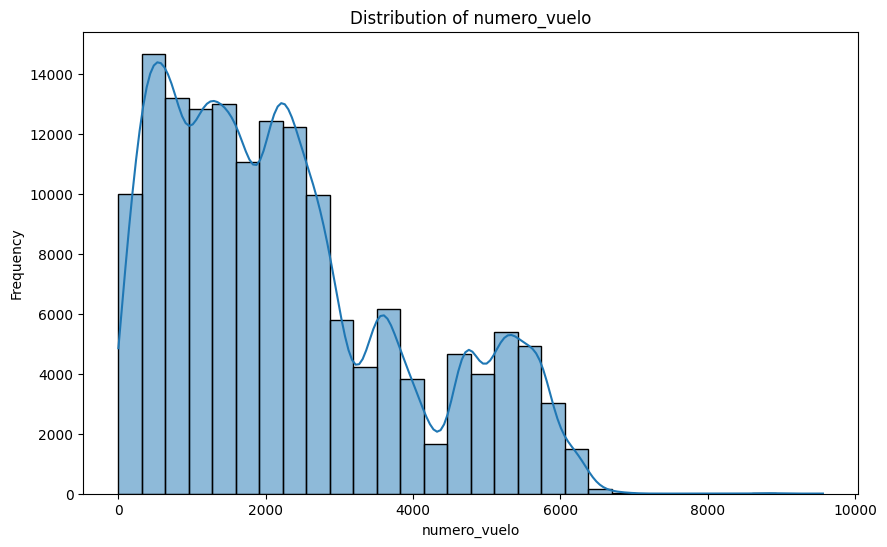

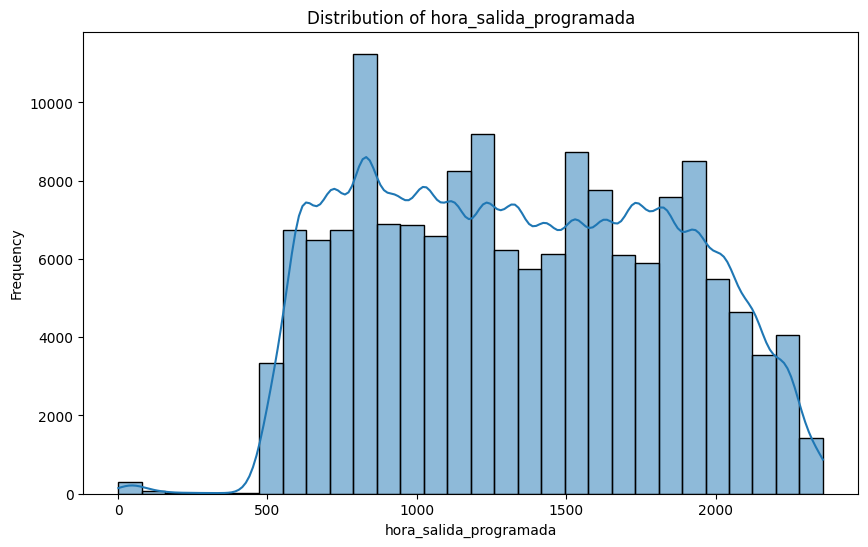

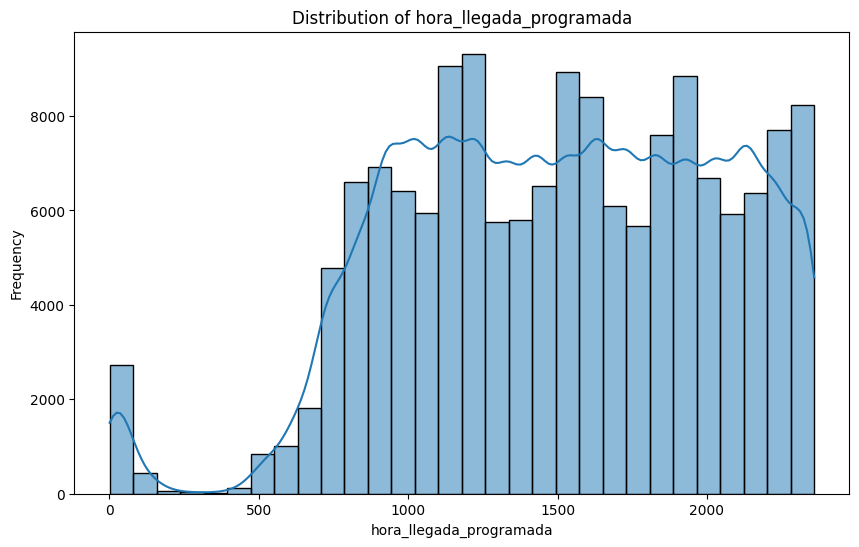

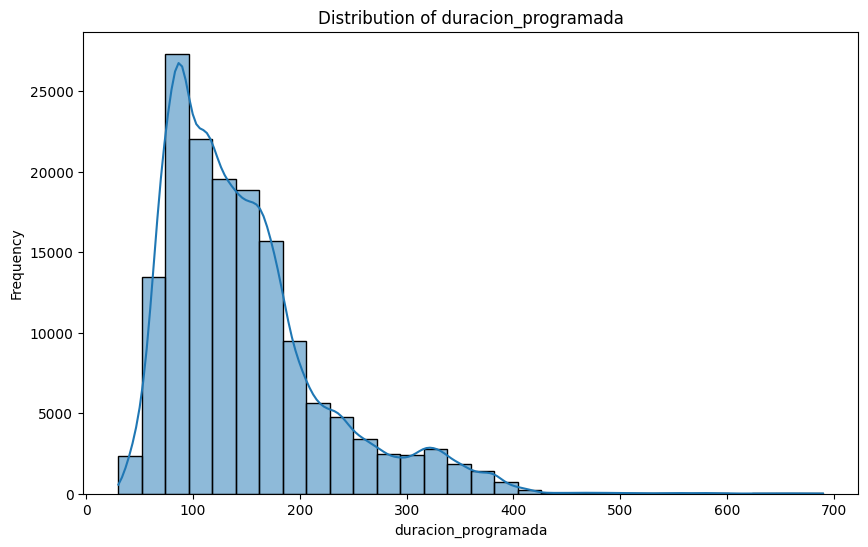

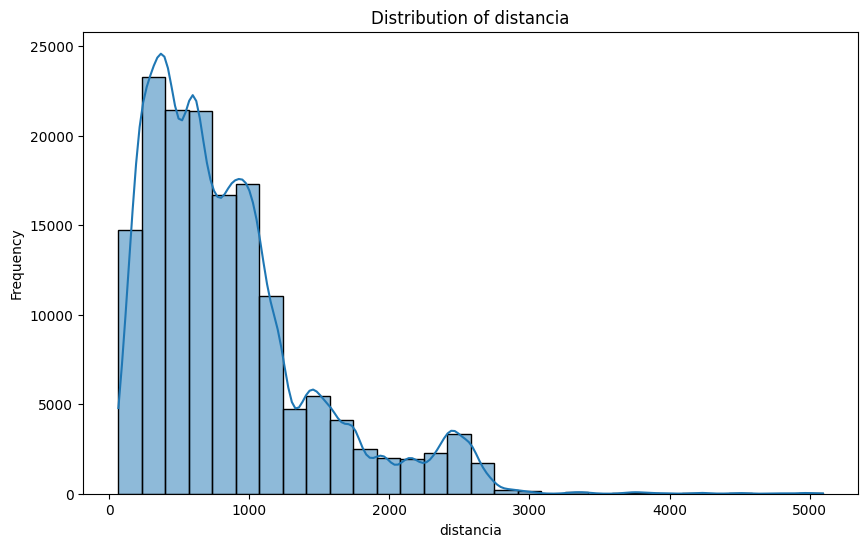

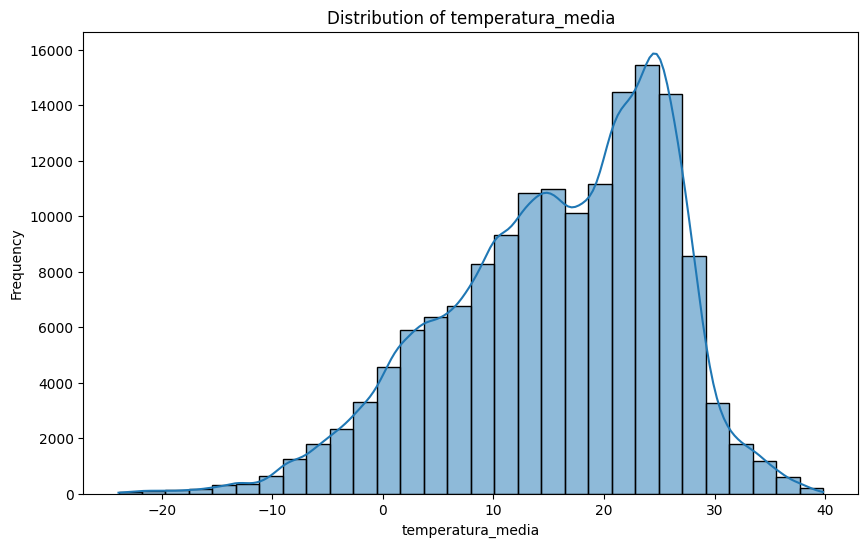

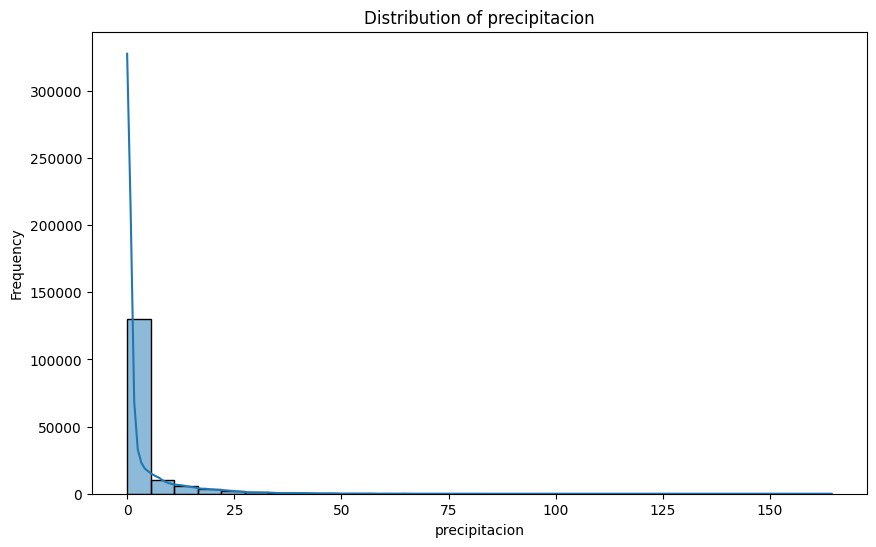

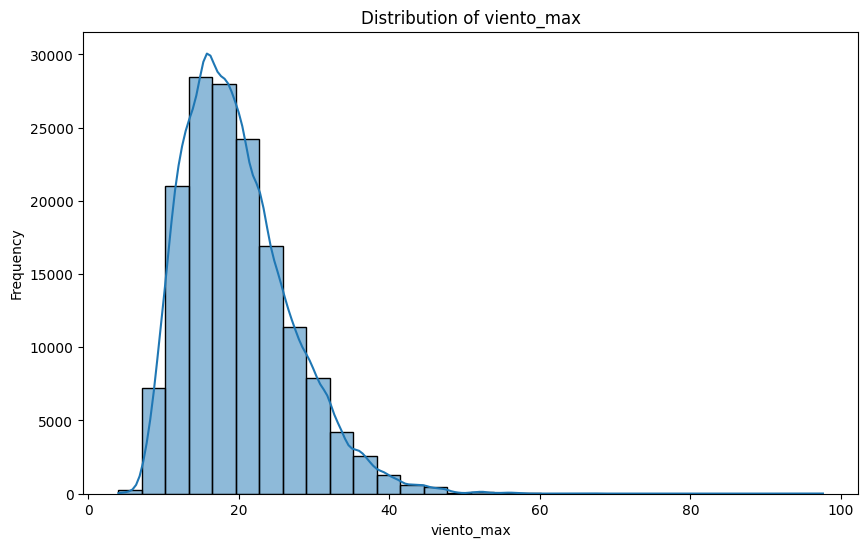

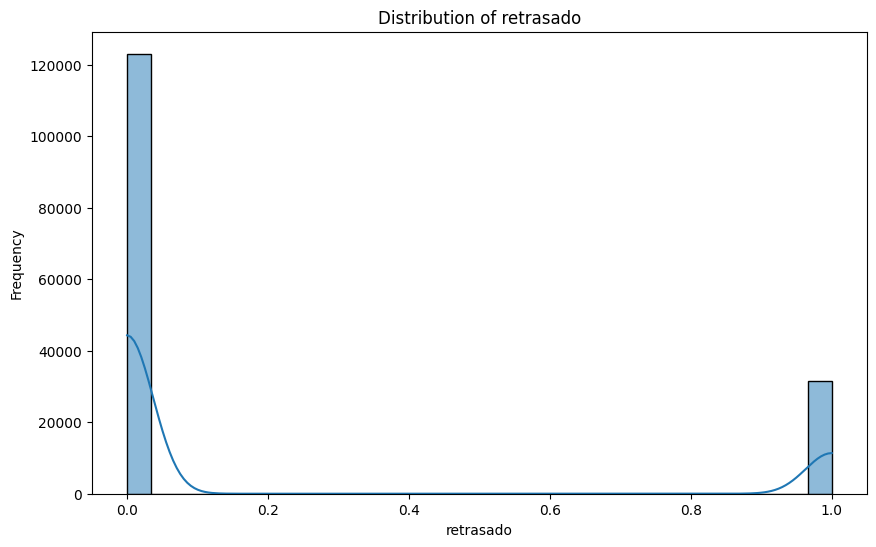

In [61]:
#quiero graficar la distribución de las variables numéricas para ver si hay alguna que tenga una distribución anormal.
for col in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_2022[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Ánalisis Univariado

In [62]:
#Análisis univariado de las variables categóricas
resumen= pd.DataFrame({
    'Media':df_modelo[numerical_columns].mean(), 
    'Mediana':df_modelo[numerical_columns].median(),
    'Moda':df_modelo[numerical_columns].mode().iloc[0],
    'Desviación Estándar':df_modelo[numerical_columns].std(),
    'IQR':df_modelo[numerical_columns].quantile(0.75) - df_modelo[numerical_columns].quantile(0.25),
    'Skewness':df_modelo[numerical_columns].skew()}).round(3)
print('Resumen estadístico de las variables numéricas:')
print(resumen)

Resumen estadístico de las variables numéricas:
                            Media  Mediana    Moda  Desviación Estándar  \
numero_vuelo             2295.423   2002.0   772.0             1635.685   
hora_salida_programada   1344.282   1328.0   600.0              494.489   
hora_llegada_programada  1498.314   1521.0  2359.0              525.940   
duracion_programada       147.299    130.0    85.0               73.998   
distancia                 852.331    696.0   337.0              609.224   
temperatura_media          15.850     17.3    25.4                9.977   
precipitacion               2.961      0.0     0.0                7.573   
viento_max                 19.792     18.7    15.5                7.113   
retrasado                   0.204      0.0     0.0                0.403   

                             IQR  Skewness  
numero_vuelo             2304.75     0.717  
hora_salida_programada    828.00     0.086  
hora_llegada_programada   827.00    -0.324  
duracion_programada  

In [63]:
# Conteo absoluto
conteo = df_modelo['retrasado'].value_counts()
print("Conteo de vuelos:")
print(conteo)

# Porcentaje
porcentaje = df_modelo['retrasado'].value_counts(normalize=True) * 100
print("\nPorcentaje de vuelos:")
print(porcentaje.round(2))

Conteo de vuelos:
retrasado
0    123038
1     31548
Name: count, dtype: int64

Porcentaje de vuelos:
retrasado
0    79.59
1    20.41
Name: proportion, dtype: float64


Por lo que podemos ver en esta parte del código podríamos decir que existe un desbalanceo de clases ya que el 20% del dataset son vuelos con retrasos y el otro 80% son vuelos que salieron a tiempo. Por lo que, a la hora de entrenar el modelo no deberíamos mirar únicamente el accuracy y además vamos a tener que realizar un balanceo de clases

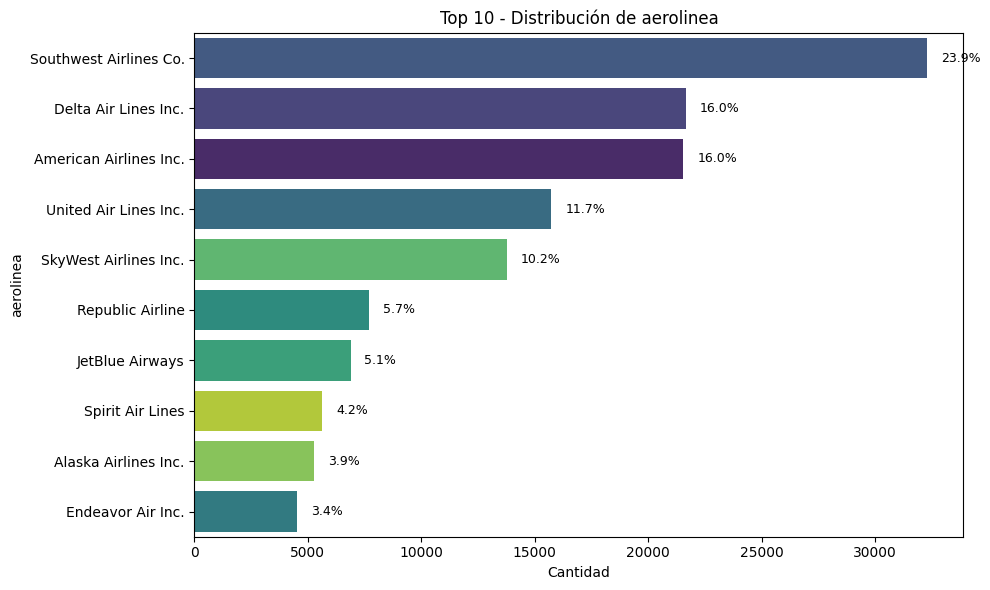

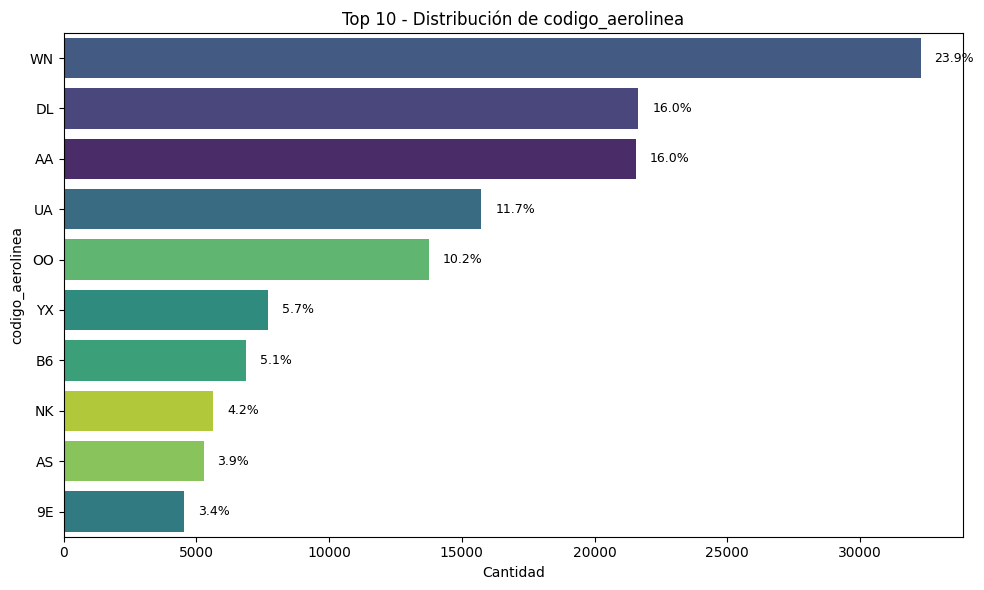

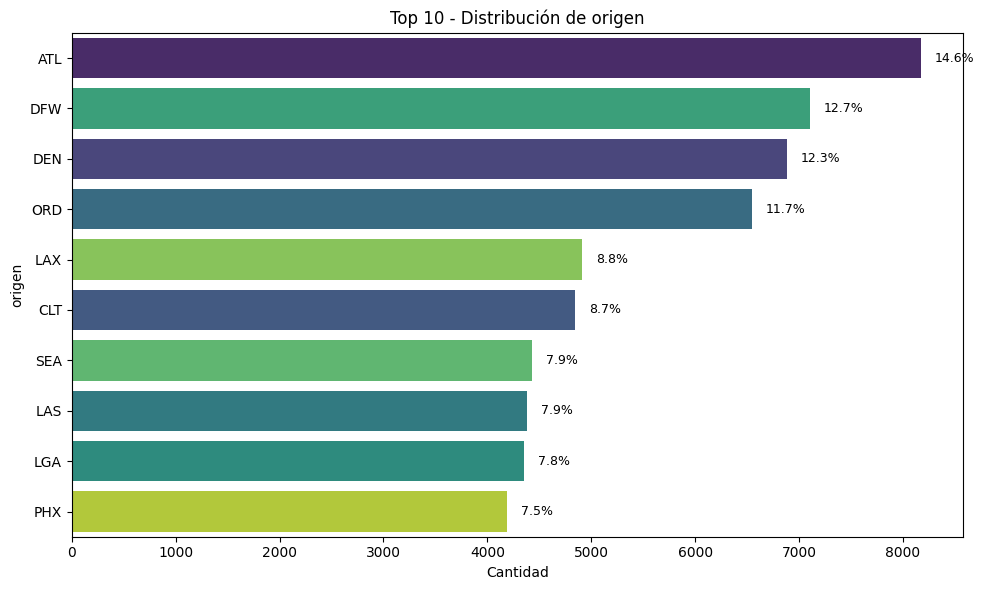

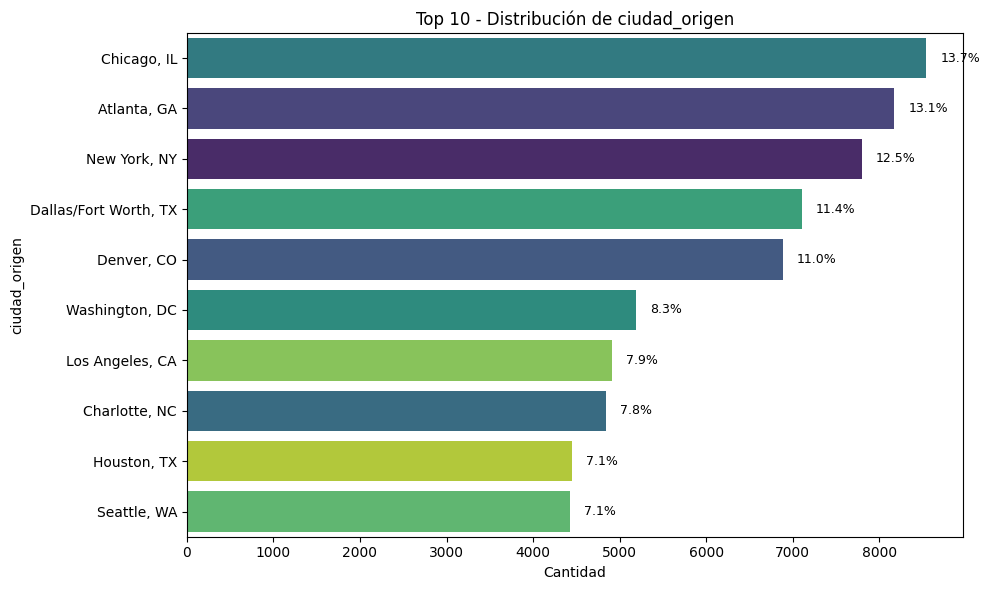

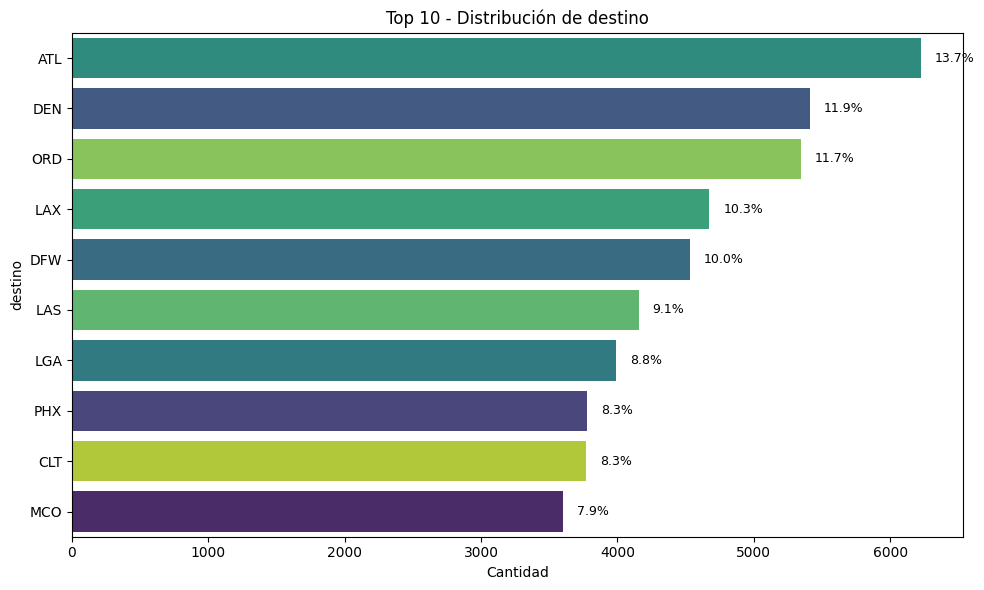

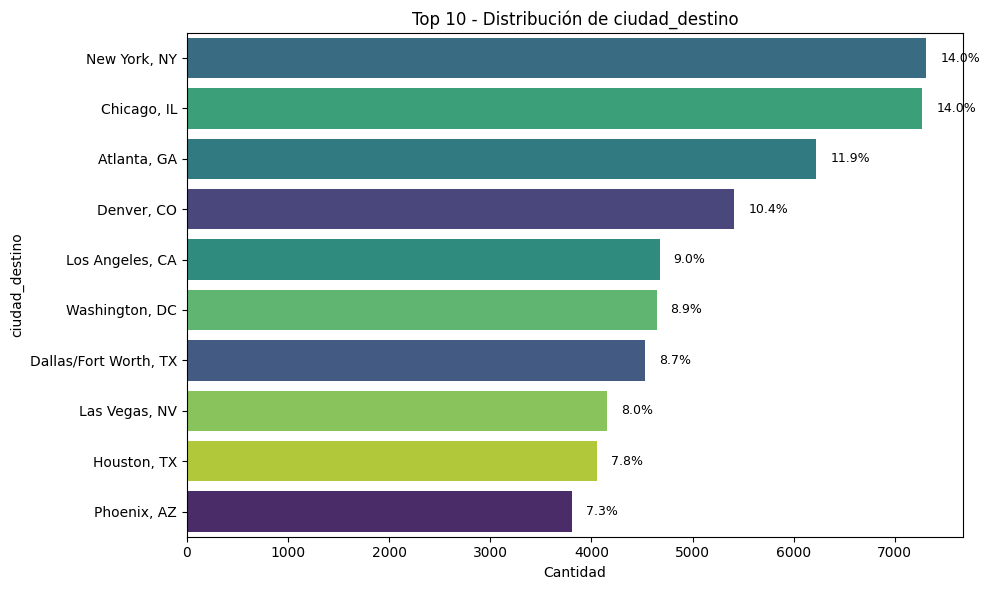

In [64]:
for col in categorical_columns:
    top10 = df_modelo[col].value_counts().nlargest(10).index
    df_top10 = df_modelo[df_modelo[col].isin(top10)]

    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df_top10, y=col, hue=col, palette='viridis', legend=False, order=top10)
    plt.title(f'Top 10 - Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)

    total = len(df_top10)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(percentage, (x, y), ha='left', va='center', fontsize=9, color='black', xytext=(10, 0), textcoords='offset points')

    plt.tight_layout()
    plt.show()

Condición climática

La mayoría de los vuelos se registraron bajo condiciones de cielo mayormente nublado o despejado, mientras que las condiciones de con viento y lluevia representan una proción minoritaria, lo que nos da a entender que el clima adverso no es lo más usual.

mostly_cloudy: 32.7%
fair: 18.1%
cloudy: 17.9%

Por otro lado, existe una fuerte concnetración en pocos aeropuertos como LAX (Los Ángeles) con un 25%, seguido por SFO (San Francisco) con un 14% y luego BOS (Boston) con un 10.4%. Lo cual nos puede indicar que la mayoría de los vuelos son más para el Oeste de EEUU.

Por último, podemos ver que las aerolíneas con mayor cantidad de vuelos son JetBlue con un 33.3% y Delta con un 26.6% representan en conjunto un 60% de los vuelos.